In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
from lobster import *

In [3]:
ticker = "AMZN"
message_path  = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_message_5.csv"
orderbook_path = f"data/LOBSTER_SampleFile_{ticker}_2012-06-21_5/{ticker}_2012-06-21_34200000_57600000_orderbook_5.csv"
levels=5
K=5

msg, ob, qr, df = load_lobster_data(message_path, orderbook_path, levels=levels, K=K)
#[["type", "lvl", "size", "P_1", "Q_1", "P_-1", "Q_-1", "P_2", "Q_2", "P_-2", "Q_-2", "P_3", "Q_3", "P_-3", "Q_-3", "P_4", "Q_4", "P_-4", "Q_-4", "P_5", "Q_5", "P_-5", "Q_-5"]]
df

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.190226,0.190226,0.190226,M,2238100,-1,21,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
1,34200.190226,0.000000,0.000000,M,2237500,-1,26,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
2,34200.372780,0.182553,0.182553,M,2238400,1,100,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
3,34200.375671,0.002892,0.002892,M,2238400,1,100,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
4,34200.383971,0.008300,0.008300,M,2238600,1,100,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28819,57599.402707,0.121990,0.000000,M,2205100,-1,91,2205550.0,2205600.0,0,...,0,2205900.0,0,2205200.0,0,2206000.0,0,2205100.0,309,9605
28820,57599.502960,0.100254,0.000000,C,2206100,5,100,2205650.0,2205700.0,0,...,0,2206000.0,0,2205300.0,0,2206100.0,0,2205200.0,0,9606
28821,57599.545828,0.042868,0.042868,M,2205100,-1,9,2205650.0,2205700.0,0,...,0,2206000.0,0,2205300.0,0,2206100.0,0,2205200.0,0,9606
28822,57599.545828,0.000000,0.000000,M,2205100,-1,51,2205650.0,2205700.0,0,...,0,2206000.0,0,2205300.0,0,2206100.0,0,2205200.0,0,9606


In [4]:
table1 = make_descriptive_table(df, K=5)
table1

,#L (×10^3),#C (×10^3),#M (×10^2),AES,AIT (ms)
Level,,,,,
1,0.80,0.36,114.18,84.98,479.1
2,1.07,0.73,0.00,168.62,285.0
3,1.62,1.26,0.00,116.56,494.9
4,2.53,2.10,0.00,106.81,678.3
5,3.70,3.25,0.00,95.70,808.9


In [5]:
aes = compute_aes_by_level(df, K=5, lvl_col="lvl", size_col="size") 
df_norm = normalize_by_aes(df, aes=aes, K=5)
df_norm.head(10)

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.190226,0.190226,0.190226,M,2238100,-1,1,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
1,34200.190226,0.000000,0.000000,M,2237500,-1,1,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
2,34200.372780,0.182553,0.182553,M,2238400,1,2,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
3,34200.375671,0.002892,0.002892,M,2238400,1,2,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
4,34200.383971,0.008300,0.008300,M,2238600,1,2,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
5,34200.385816,0.001844,0.001844,M,2238600,1,2,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
6,34200.387205,0.001389,0.001389,M,2239200,1,2,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
7,34200.388463,0.001258,0.001258,M,2239300,1,2,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
8,34200.391413,0.002950,0.002950,M,2239500,1,2,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1
9,34200.391413,0.000000,0.000000,M,2239600,1,1,2238550.0,2238600.0,0,...,0,2238900.0,0,2238200.0,0,2239000.0,0,2238100.0,0,1


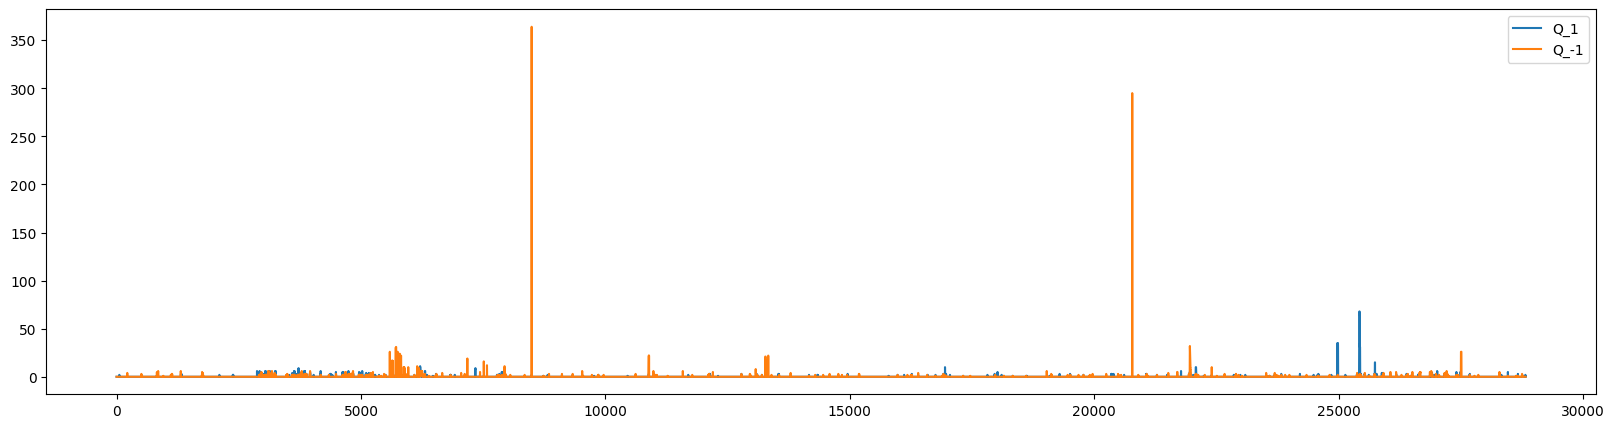

In [6]:
plt.figure(figsize=(20, 5))
for i in range(1,2):
    plt.plot(df_norm[f"Q_{i}"], label=f"Q_{i}")
    plt.plot(df_norm[f"Q_-{i}"], label=f"Q_-{i}")
plt.legend()
plt.show()

### Training DataFrame: ###
From where we will extract our different state vectors $x_k$.

In [7]:
df_train = df_norm.copy()

# 1) event id
event_map = {"L": 0, "C": 1, "M": 2}
df_train["event_id"] = df_train["type"].map(event_map).astype("int64")

# 2) hour
df_train["hour"] = (df_train["time"] // 3600).astype("int64")
hour_map = {h: i for i, h in enumerate(sorted(df_train["hour"].unique()))}
df_train["hour_id"] = df_train["hour"].map(hour_map).astype("int64")

# 3) last event id
df_train["last_event_id"] = df_train["event_id"].shift(1).fillna(0).astype("int64")

# 4) pre-event queues within each constant-pref segment
def _q_event_row(row):
    idx = row.name
    if idx == 0:
        return np.nan 
    prev = df_train.iloc[idx - 1]  # previous row
    l = int(row["lvl"])
    if l == 0:
        return np.nan
    return prev[f"Q_{l}"]
df_train["q_event"] = df_train.apply(_q_event_row, axis=1).astype("float64")

# 5) clean dataframe of nan
df_train = df_train.dropna().reset_index(drop=True)

# 5) keep only what you need
df_train = df_train[["q_event", "hour", "hour_id", "last_event_id", "event_id", "dtk_l"]].copy()
df_train

,q_event,hour,hour_id,last_event_id,event_id,dtk_l
0,0.0,9,0,2,2,0.000000
1,0.0,9,0,2,2,0.182553
2,0.0,9,0,2,2,0.002892
3,0.0,9,0,2,2,0.008300
4,0.0,9,0,2,2,0.001844
...,...,...,...,...,...,...
28818,0.0,15,6,1,2,0.000000
28819,0.0,15,6,2,1,0.000000
28820,0.0,15,6,1,2,0.042868
28821,0.0,15,6,2,2,0.000000


### Training / Target vectors: ###

Vanilla : $x_k = [q_k]$

Hours: $x_k = [q_k, h_k]$

Last Event: $x_k = [q_k, \eta_{k-1}]$

Hours + Last Event: $x_k = [q_k, h_k, \eta_{k-1}]$

In [8]:
from dqrfunctions import build_dataset

data_vanilla = build_dataset(df_train, use_hour=False, use_last_event=False)
data_hour = build_dataset(df_train, use_hour=True, use_last_event=False)
data_last_event = build_dataset(df_train, use_hour=False, use_last_event=True)
data_hour_last_event = build_dataset(df_train, use_hour=True, use_last_event=True)

display(data_hour_last_event)

{'q': tensor([0., 0., 0.,  ..., 0., 0., 0.]),
 'y': tensor([2, 2, 2,  ..., 2, 2, 1]),
 'dt': tensor([0.0000, 0.1826, 0.0029,  ..., 0.0429, 0.0000, 0.0000]),
 'last_event': tensor([2, 2, 2,  ..., 1, 2, 2]),
 'hour_id': tensor([0, 0, 0,  ..., 6, 6, 6])}

### Neural Network Definition ###

In [9]:
from dqrfunctions import DQRNet

### Negative Log Likelihood ###

$\text{loss}\left(\theta | \epsilon\right) = l\left(\lambda_\theta | \epsilon\right) = \sum_{i=1}^{B} \left( \Lambda_\theta(x_k)\Delta t_k - \log{\lambda_\theta^{\eta_k}(x_k)} \right)$

In [10]:
from dqrfunctions import dqr_loss

### Training Loop ###

In [11]:
from dqrfunctions import train_model, get_or_train_model

### Vanilla Model ###

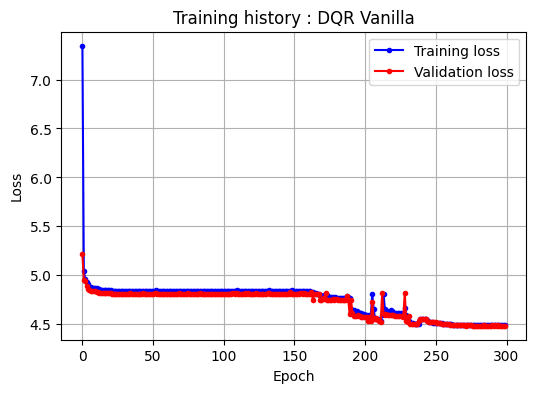

In [12]:
model_vanilla = get_or_train_model(
    f"models/{ticker}/dqr_vanilla.pt",
    data=data_vanilla,
    compute_model=False,
    use_hour=False,
    use_last_event=False)
model_vanilla.plot_history(model_name="Vanilla")

### Hour Model ###

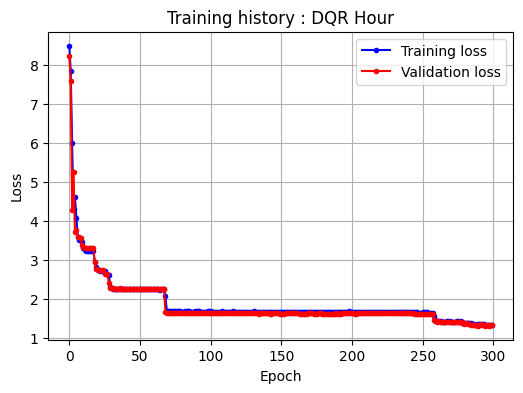

In [13]:
model_hour = get_or_train_model(
    f"models/{ticker}/dqr_hour.pt",
    data=data_hour,
    compute_model=False,
    use_hour=True,
    use_last_event=False,
    hour_num_classes=df_train["hour_id"].nunique())
model_hour.plot_history(model_name="Hour")

### Last-Event Model ###

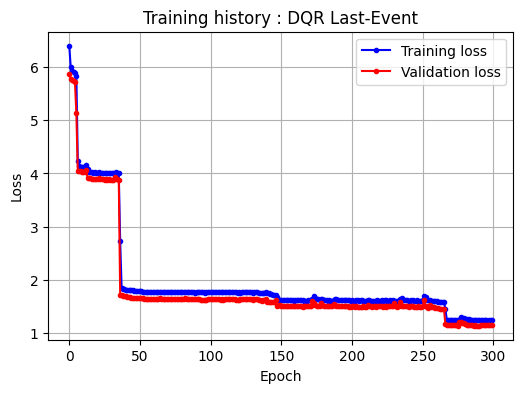

In [14]:
model_last_event = get_or_train_model(
    f"models/{ticker}/dqr_last_event.pt",
    data=data_last_event,
    compute_model=False,
    use_hour=False,
    use_last_event=True)
model_last_event.plot_history(model_name="Last-Event")

### Hour + Last-Event Model ###

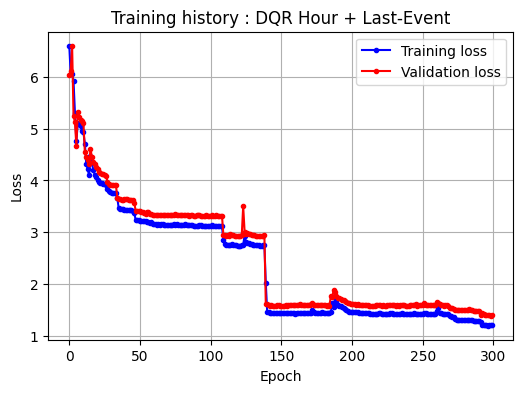

In [15]:
model_hour_last_event = get_or_train_model(
    f"models/{ticker}/dqr_hour_last_event.pt",
    data=data_hour_last_event,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=df_train["hour_id"].nunique())
model_hour_last_event.plot_history(model_name="Hour + Last-Event")

In [21]:
from dqrfunctions import transition_real, transition_dqr

event_id_np = df_train["event_id"].to_numpy()
last_id_np  = df_train["last_event_id"].to_numpy()
# DQR: last_event_id must match X lines format (torch)
last_id_t = torch.tensor(last_id_np, dtype=torch.long)

T_real = transition_real(event_id_np, last_id_np, n_events=3)
T_dqr_le = transition_dqr(
                        model=model_last_event,
                        data=data_last_event,
                        last_event_id=last_id_t,
                        n_events=3)
T_dqr_h_le = transition_dqr(
                        model=model_hour_last_event,
                        data=data_hour_last_event,
                        last_event_id=last_id_t,
                        n_events=3)

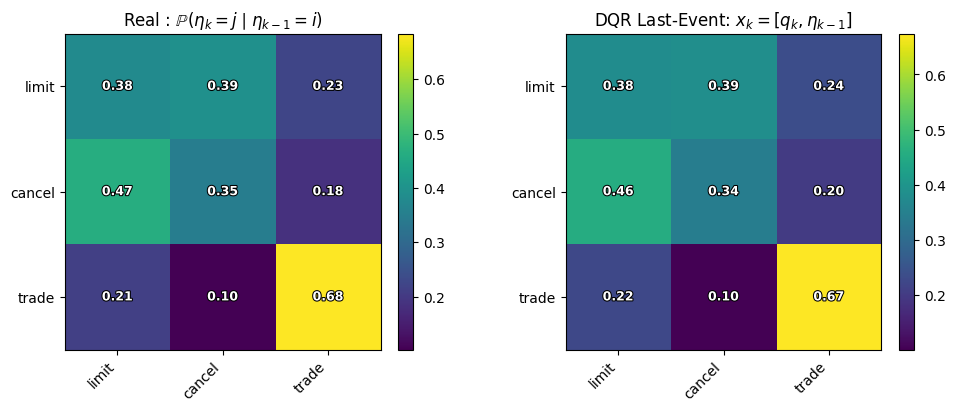

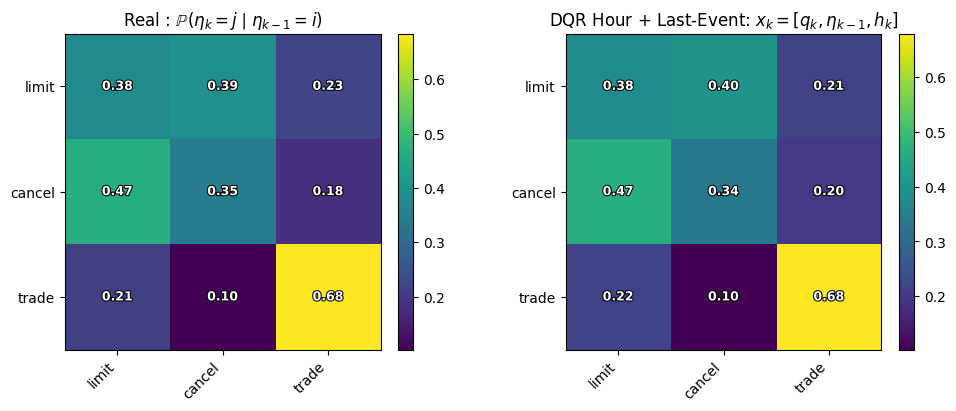

In [22]:
from dqrfunctions import plot_two_heatmaps

EVENT_NAMES = ["limit", "cancel", "trade"]
dqr_last_event_title = r"DQR Last-Event: $x_k=[q_k,\eta_{k-1}]$"
dqr_hour_last_event_title = r"DQR Hour + Last-Event: $x_k=[q_k,\eta_{k-1},h_k]$"

fig = plot_two_heatmaps(T_real, T_dqr_le, labels=EVENT_NAMES, dqr_title=dqr_last_event_title)
plt.show()
fig = plot_two_heatmaps(T_real, T_dqr_h_le, labels=EVENT_NAMES, dqr_title=dqr_hour_last_event_title)
plt.show()

In [18]:
@torch.no_grad()
def compute_hourly_intensity(model, data, hour_values):
    model.eval()

    # Forward according to model type
    if model.use_hour and model.use_last_event:
        lambdas = model(
            data["q"],
            last_event=data["last_event"],
            hour=data["hour_id"]
        )

    elif model.use_hour:
        lambdas = model(
            data["q"],
            hour=data["hour_id"]
        )

    elif model.use_last_event:
        lambdas = model(
            data["q"],
            last_event=data["last_event"]
        )

    else:
        lambdas = model(data["q"])

    lambdas = lambdas.cpu().numpy()

    df_plot = pd.DataFrame({
        "hour_id": hour_values,
        "lambda_limit": lambdas[:, 0],
        "lambda_cancel": lambdas[:, 1],
        "lambda_trade": lambdas[:, 2]
    })

    hourly = df_plot.groupby("hour_id")["lambda_trade"].mean()

    return hourly

In [19]:
def compute_real_hourly_intensity(df, trade_id=2):
    df_real = df.copy()

    # total observation time per hour
    total_time = df_real.groupby("hour")["dtk_l"].sum()

    # number of trade events per hour
    n_trades = (df_real["event_id"] == trade_id).groupby(df_real["hour"]).sum()

    # empirical intensity = count / total time
    lambda_real = n_trades / total_time

    return lambda_real

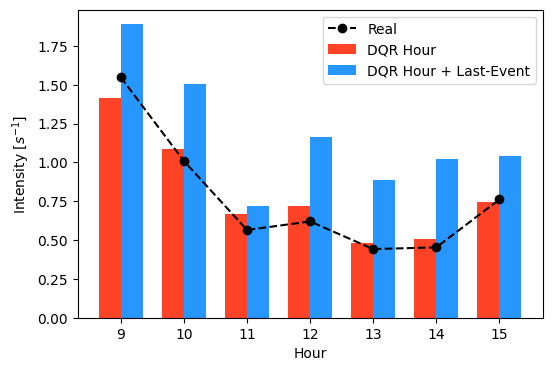

In [20]:
hourly_dqr_h = compute_hourly_intensity(model_hour, data_hour, df_train["hour"].values)
hourly_dqr_h_le = compute_hourly_intensity(model_hour_last_event, data_hour_last_event, df_train["hour"].values)
hourly_real = compute_real_hourly_intensity(df_train, trade_id=2)

width = 0.35
x = hourly_dqr_h.index.values
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(x - width/2, hourly_dqr_h.values, width=width, color="#FF4327", label="DQR Hour")
ax.bar(x + width/2, hourly_dqr_h_le.values, width=width, color="#2797FF", label="DQR Hour + Last-Event")
ax.plot(x, hourly_real.values, "o--", color="black", label="Real")
ax.set_xlabel("Hour")
ax.set_ylabel(r"Intensity [$s^{-1}$]")
ax.set_xticks(x)
ax.legend()
plt.show()